# 07. Galutinė suvestinė, ribos, rizikos ir praktinis tinkamumas

Šiame etape **nekuriame naujų modelių** ir **neatliekame naujų eksperimentų**. Tik programiškai surenkame 1–6 etapų rezultatus ir parengiame galutinę analizę.

Vienintelis papildomas skaičiavimas: Majority Class TEST klaidų skaičius iš to paties split (dažniausia TRAIN klasė → TEST). k-NN / SVM / MLP klaidų skaičius imamas iš 6 etapo `misclassified_examples.csv`, be retraining.

## Duomenų ir eksperimento protokolas

Žemiau esanti santrauka tikrinama iš `subject_disjoint_split.npz` ir ankstesnių CSV. Protokolas, kurį patvirtina projekto failai:

- Duomenų rinkinys: UCI Human Activity Recognition Using Smartphones.
- Sujungtos originalios UCI train/test dalys, tada `GroupShuffleSplit`, `RANDOM_STATE=42`.
- Hiperparametrai parinkti tik TRAIN su `GroupKFold`; galutinis TEST nenaudotas tuning.
- `StandardScaler` mokomas tik iš TRAIN (2–4 etapai: Pipeline viduje; 5 etapas: aiškus `fit` prieš triukšmą).

Konkrečius skaičius (įrašai, požymiai, subject) spausdina kita celė iš split failo.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = None
for cand in candidates:
    if (cand / "results").exists() and (cand / "notebooks").exists():
        project_root = cand
        break
if project_root is None:
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

results_dir = project_root / "results"
split = np.load(results_dir / "subject_disjoint_split.npz", allow_pickle=True)

X_train = split["X_train_final"]
X_test = split["X_test_final"]
y_train = split["y_train_final"]
y_test = split["y_test_final"]
subjects_train = split["subjects_train_final"]
subjects_test = split["subjects_test_final"]
n_all = len(y_train) + len(y_test)
n_feat = X_train.shape[1]
n_subj_all = len(set(subjects_train.tolist()) | set(subjects_test.tolist()))
n_classes = len(np.unique(np.concatenate([y_train, y_test])))
overlap = sorted(set(subjects_train.tolist()) & set(subjects_test.tolist()))
rs = int(split["random_state"][0])

print(f"Visi įrašai (TRAIN+TEST): {n_all}")
print(f"Požymiai: {n_feat}")
print(f"Subject iš viso: {n_subj_all}")
print(f"Klasių: {n_classes}")
print(f"RANDOM_STATE iš split: {rs}")
print(f"TRAIN: {X_train.shape[0]} įrašai / {len(np.unique(subjects_train))} subject")
print(f"TEST: {X_test.shape[0]} įrašų / {len(np.unique(subjects_test))} subject")
print(f"TRAIN ∩ TEST subject: {overlap}")
assert n_all == 10299 and n_feat == 561 and n_subj_all == 30 and n_classes == 6
assert X_train.shape[0] == 7144 and X_test.shape[0] == 3155
assert overlap == [] and rs == 42
print("Protokolo patikra iš split: OK.")

Visi įrašai (TRAIN+TEST): 10299
Požymiai: 561
Subject iš viso: 30
Klasių: 6
RANDOM_STATE iš split: 42
TRAIN: 7144 įrašai / 21 subject
TEST: 3155 įrašų / 9 subject
TRAIN ∩ TEST subject: []
Protokolo patikra iš split: OK.


In [11]:
baseline = pd.read_csv(results_dir / "baseline_results.csv")
intel = pd.read_csv(results_dir / "intelligent_models_results.csv")
ablation = pd.read_csv(results_dir / "ablation_results.csv")
noise = pd.read_csv(results_dir / "noise_robustness_results.csv")
per_class = pd.read_csv(results_dir / "per_class_metrics.csv")
top_pairs = pd.read_csv(results_dir / "top_confusion_pairs.csv")
per_subject = pd.read_csv(results_dir / "per_subject_metrics.csv")
misc = pd.read_csv(results_dir / "misclassified_examples.csv")

metrics = pd.concat([baseline, intel], ignore_index=True)
print("Užkrauti ankstesnių etapų CSV. Naujų modelių nėra.")

Užkrauti ankstesnių etapų CSV. Naujų modelių nėra.


## Galutinė modelių palyginimo lentelė

Macro-F1 ir Balanced Accuracy — iš 2 ir 3 etapų CSV. Majority klaidos perskaičiuotos iš to paties TEST ir TRAIN majority klasės (ne naujas tuning). k-NN / SVM / MLP klaidos — 6 etapo visų klaidingų TEST eilučių skaičius.

In [12]:
values, counts = np.unique(y_train, return_counts=True)
majority_class = int(values[np.argmax(counts)])
majority_errors = int(np.sum(y_test != majority_class))
print(f"TRAIN majority klasė: {majority_class}, TEST klaidos: {majority_errors}")

err_counts = misc.groupby("Model").size().to_dict()
err_map = {
    "Majority Class": majority_errors,
    "k-NN": int(err_counts["k-NN"]),
    "SVM": int(err_counts["SVM"]),
    "MLP": int(err_counts["MLP"]),
}

order = ["Majority Class", "k-NN", "SVM", "MLP"]
metrics = metrics.set_index("Model").loc[order].reset_index()
metrics["Number of TEST Errors"] = metrics["Model"].map(err_map)
final_table = metrics[["Model", "Macro-F1", "Balanced Accuracy", "Number of TEST Errors"]]
print(final_table.to_string(index=False))

final_path = results_dir / "final_model_comparison.csv"
final_table.to_csv(final_path, index=False)
print(f"Išsaugota: {final_path}")

TRAIN majority klasė: 6, TEST klaidos: 2556
         Model  Macro-F1  Balanced Accuracy  Number of TEST Errors
Majority Class  0.053188           0.166667                   2556
          k-NN  0.844324           0.842074                    491
           SVM  0.897130           0.893666                    347
           MLP  0.896616           0.894957                    340
Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\final_model_comparison.csv


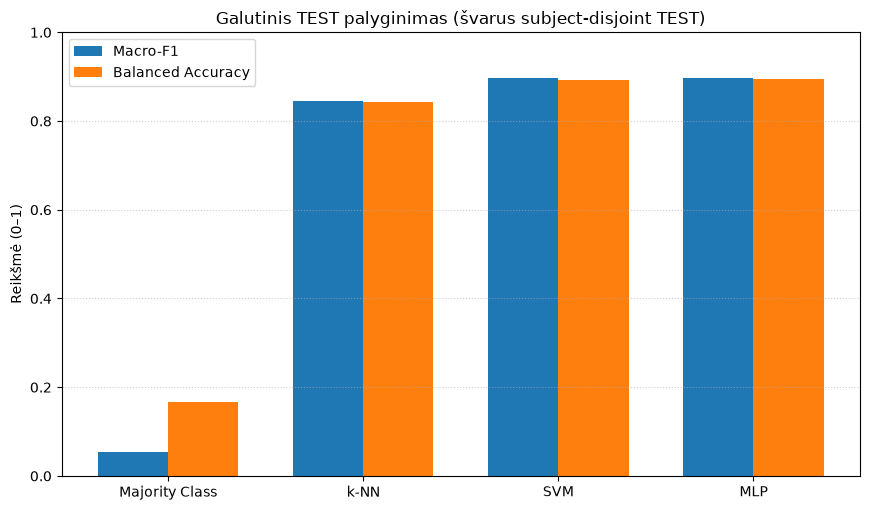

Išsaugota: final_model_comparison.svg / .png


In [13]:
fig, ax = plt.subplots(figsize=(8.8, 5.2))
x = np.arange(len(order))
w = 0.36
ax.bar(x - w / 2, final_table["Macro-F1"], w, label="Macro-F1")
ax.bar(x + w / 2, final_table["Balanced Accuracy"], w, label="Balanced Accuracy")
ax.set_xticks(x, order)
ax.set_ylabel("Reikšmė (0–1)")
ax.set_ylim(0.0, 1.0)
ax.set_title("Galutinis TEST palyginimas (švarus subject-disjoint TEST)")
ax.legend()
ax.grid(axis="y", linestyle=":", alpha=0.6)
fig.tight_layout()
fig.savefig(results_dir / "final_model_comparison.svg", format="svg")
fig.savefig(results_dir / "final_model_comparison.png", format="png", dpi=200)
plt.show()
print("Išsaugota: final_model_comparison.svg / .png")

## Pagrindinių modelių interpretacija

Skaičiai — iš lentelės aukščiau (2/3/6 etapai), ne ranka įrašyti nauji eksperimentai.

**FAKTAI.** Majority Class TEST Macro-F1 ir Balanced Accuracy yra žemi (apie 0.053 ir 0.167) — tai dummy atskaitos taškas. k-NN aiškiai lenkia Majority, bet atsilieka nuo SVM ir MLP. SVM Macro-F1 yra šiek tiek aukštesnis nei MLP; MLP Balanced Accuracy šiek tiek aukštesnis; MLP TEST klaidų šiek tiek mažiau. Skirtumai tarp SVM ir MLP yra maži.

Projekto pagrindinė parinkimo metrika buvo Macro-F1. **Pagal šią konkrečią metriką** SVM gavo didžiausią galutinio TEST reikšmę. Tai nereiškia, kad SVM apskritai yra geriausias HAR metodas: pagal Balanced Accuracy ir bendrą klaidų skaičių MLP nežymiai priekyje. „Laimėjo / nelaimėjo“ priklauso nuo pasirinkto kriterijaus.

## Abliacijos suvestinė

In [14]:
print(ablation.to_string(index=False))
print()
for model in ["k-NN", "SVM", "MLP"]:
    sub = ablation[ablation["Model"] == model].set_index("Feature Group")
    all_best = sub["Macro-F1"].idxmax() == "All"
    acc_gt_gyro = sub.loc["Accelerometer", "Macro-F1"] > sub.loc["Gyroscope", "Macro-F1"]
    print(
        f"{model}: All geriausias={all_best}; Acc>Gyro={acc_gt_gyro}; "
        f"dAcc={sub.loc['Accelerometer', 'Delta Macro-F1 vs All']:+.6f}; "
        f"dGyro={sub.loc['Gyroscope', 'Delta Macro-F1 vs All']:+.6f}"
    )

Model Feature Group  Number of Features  Macro-F1  Balanced Accuracy  Delta Macro-F1 vs All
 k-NN Accelerometer                 348  0.809685           0.807238              -0.034639
 k-NN     Gyroscope                 211  0.690462           0.695358              -0.153862
 k-NN           All                 561  0.844324           0.842074               0.000000
  SVM Accelerometer                 348  0.855685           0.849897              -0.041445
  SVM     Gyroscope                 211  0.797924           0.800521              -0.099206
  SVM           All                 561  0.897130           0.893666               0.000000
  MLP Accelerometer                 348  0.861582           0.858659              -0.035033
  MLP     Gyroscope                 211  0.750806           0.754498              -0.145809
  MLP           All                 561  0.896616           0.894957               0.000000

k-NN: All geriausias=True; Acc>Gyro=True; dAcc=-0.034639; dGyro=-0.153862
SVM: 

**FAKTAI (šis dataset, šie engineered features, šis split).** All features visiems trims modeliams davė didžiausią Macro-F1. Accelerometer-only visiems trims buvo geriau už Gyroscope-only. Acc-only praradimas vs All apie −0.035 … −0.041; Gyro-only apie −0.099 … −0.154.

Tai **neįrodo** akselerometro svarbos visiems HAR atvejams ar kitiems požymių rinkiniams.

## Robustness suvestinė

In [15]:
print(noise.to_string(index=False))
print()
drop = []
for model in ["k-NN", "SVM", "MLP"]:
    s0 = noise[(noise["Model"] == model) & (noise["Noise Sigma"] == 0.0)].iloc[0]
    s5 = noise[(noise["Model"] == model) & (noise["Noise Sigma"] == 0.5)].iloc[0]
    d = s0["Macro-F1"] - s5["Macro-F1"]
    drop.append((model, float(s0["Macro-F1"]), float(s5["Macro-F1"]), float(d)))
    print(
        f"{model}: sigma0={s0['Macro-F1']:.6f}, sigma0.5={s5['Macro-F1']:.6f}, drop={d:.6f}"
    )
drop_sorted = sorted(drop, key=lambda t: t[3], reverse=True)
print(f"Daugiausiai prarado: {drop_sorted[0][0]}; mažiausiai: {drop_sorted[-1][0]}")

Model  Noise Sigma  Macro-F1  Balanced Accuracy  Delta Macro-F1 vs sigma=0
 k-NN          0.0  0.844324           0.842074                   0.000000
 k-NN          0.1  0.844294           0.842156                  -0.000029
 k-NN          0.2  0.849383           0.847187                   0.005059
 k-NN          0.3  0.844879           0.842720                   0.000556
 k-NN          0.5  0.841872           0.839668                  -0.002451
  SVM          0.0  0.897130           0.893666                   0.000000
  SVM          0.1  0.897725           0.894106                   0.000595
  SVM          0.2  0.888484           0.884236                  -0.008645
  SVM          0.3  0.884625           0.880232                  -0.012505
  SVM          0.5  0.859410           0.853724                  -0.037720
  MLP          0.0  0.896616           0.894957                   0.000000
  MLP          0.1  0.901872           0.900225                   0.005256
  MLP          0.2  0.898

**FAKTAI.** Šiame teste k-NN Macro-F1 pakito mažiausiai (σ=0 → 0.5), SVM prarado daugiausiai, MLP — tarp jų. Kai kuriuose mažo sigma taškuose (pvz. k-NN σ=0.2, MLP σ=0.1) Macro-F1 buvo šiek tiek aukštesnis nei σ=0. Tai **nėra įrodymas**, kad triukšmas gerina modelį — vienos realizacijos svyravimas.

**Eksperimento riba.** Sintetinis Gaussian noise standartizuotoje 561 požymių erdvėje; ne fizinio IMU modelis. Kiekvienam sigma naudota **viena** deterministinė realizacija, todėl dispersija tarp daugelio triukšmo traukinių neįvertinta.

## Klaidų analizės suvestinė

In [16]:
print("TOP klaidų poros:")
print(top_pairs.to_string(index=False))
print()
print("Žemiausias klasės F1 kiekvienam modeliui:")
idx = per_class.groupby("Model")["F1-score"].idxmin()
print(per_class.loc[idx, ["Model", "Class", "F1-score", "Recall"]].to_string(index=False))
print()
print("Realūs klaidingi pavyzdžiai (pirmi unikalūs pagal modelį iš CSV):")
examples = misc.groupby("Model", sort=False).head(1)[
    ["Model", "Test Row Index", "Subject ID", "True Class", "Predicted Class"]
]
print(examples.to_string(index=False))
extra = misc[
    (misc["Model"] == "SVM") & (misc["Test Row Index"] == 6)
][
    ["Model", "Test Row Index", "Subject ID", "True Class", "Predicted Class"]
]
if len(extra):
    print(extra.to_string(index=False))

TOP klaidų poros:
Model         True Class  Predicted Class  Count  Percent of True Class
 k-NN            SITTING         STANDING    118               0.216912
 k-NN WALKING_DOWNSTAIRS WALKING_UPSTAIRS     86               0.197248
 k-NN           STANDING          SITTING     74               0.126712
 k-NN             LAYING         STANDING     66               0.110184
 k-NN WALKING_DOWNSTAIRS          WALKING     48               0.110092
  SVM           STANDING          SITTING     97               0.166096
  SVM             LAYING         STANDING     83               0.138564
  SVM            SITTING         STANDING     70               0.128676
  SVM   WALKING_UPSTAIRS          SITTING     59               0.121901
  SVM WALKING_DOWNSTAIRS WALKING_UPSTAIRS     18               0.041284
  MLP           STANDING          SITTING    106               0.181507
  MLP            SITTING         STANDING     74               0.136029
  MLP             LAYING         STANDING     

**FAKTAI.** Visuose trijuose modeliuose dažna SITTING ↔ STANDING painiava. Taip pat visuose yra LAYING → STANDING. k-NN ir MLP turi WALKING_DOWNSTAIRS → WALKING_UPSTAIRS; k-NN dar WALKING_DOWNSTAIRS → WALKING. Žemiausias klasės F1: k-NN SITTING; SVM ir MLP STANDING.

Pavyzdžiai imami iš `misclassified_examples.csv` (aukščiau esanti celė), ne sugalvoti.

**HIPOTEZĖ (neįrodyta).** Statinės veiklos (sėdėjimas / stovėjimas) gali turėti panašesnius engineered požymius; tai nėra šiame projekte įrodytas mechanizmas.

## Generalizacija į nematytus subject

In [17]:
print("TEST subject:", sorted(per_subject["Subject ID"].unique().tolist()))
print("N True Classes unikalios reikšmės:", sorted(per_subject["N True Classes"].unique().tolist()))
print()
for model in ["k-NN", "SVM", "MLP"]:
    sub = per_subject[per_subject["Model"] == model]
    print(
        f"{model}: n_subject={sub['Subject ID'].nunique()}, "
        f"Macro-F1 min={sub['Macro-F1'].min():.4f}, max={sub['Macro-F1'].max():.4f}, "
        f"mean={sub['Macro-F1'].mean():.4f}"
    )

TEST subject: [9, 10, 13, 16, 18, 24, 25, 28, 29]
N True Classes unikalios reikšmės: [6]

k-NN: n_subject=9, Macro-F1 min=0.7262, max=0.9613, mean=0.8358
SVM: n_subject=9, Macro-F1 min=0.7155, max=1.0000, mean=0.8922
MLP: n_subject=9, Macro-F1 min=0.7433, max=0.9918, mean=0.8934


**FAKTAS.** TEST — 9 subject, kurių nebuvo TRAIN. Visi jie turi 6 klases. Bendras TEST Macro-F1 **neparodo** visos variacijos: SVM subject Macro-F1 siekia nuo ~0.72 iki 1.00, k-NN ir MLP taip pat turi platų diapazoną. Tai generalizacijos riba **šiame** rinkinyje, ne žmonių reitingas ir ne išvada apie jų savybes.

## Sprendimo ribos

1. Naudojamas tik vienas UCI HAR dataset.
2. TEST subject nematyti mokymo metu, bet jie vis tiek iš to paties rinkinio ir tos pačios eksperimentinės aplinkos.
3. Tai neįrodo generalizacijos į kitą telefono modelį, kitą sensorių, kitą laikymo vietą, kitą sampling konfigūraciją, kitą populiaciją ar nekontroliuojamą aplinką.
4. Naudojami jau apskaičiuoti 561 engineered features, ne end-to-end raw IMU modelis.
5. Synthetic Gaussian noise robustness nėra tikslus fizinio IMU triukšmo modelis.
6. Kiekvienam sigma naudota viena deterministinė noise realizacija.
7. Modelių palyginimas priklauso nuo pasirinktų hiperparametrų paieškos erdvių (siauri tinkleliai 2–3 etapuose).
8. SVM ir MLP rezultatai labai artimi, todėl iš šio vieno TEST nereikia daryti stiprios išvados apie absoliutų vieno metodo pranašumą.

## Rizikos

**Rizikos, kurias parodė šio projekto eksperimentai:**
- klaidingas veiklos atpažinimas (šimtai TEST klaidų visuose modeliuose);
- painiojamos panašios veiklos (SITTING ↔ STANDING, dalis walking porų, LAYING → STANDING);
- nevienodas veikimas skirtingiems nematytiems TEST subject;
- kokybės kritimas, kai paliekami tik giroskopo požymiai;
- SVM/MLP Macro-F1 kritimas esant didesniam sintetiniam Gauso triukšmui (σ=0.5).

**Rizikos, galimos praktiniame diegime, bet čia **netestuotos** tiesiogiai:**
- domain shift (kitas telefonas, populiacija, aplinka);
- realus sensoriaus bias / drift / koreliuotas IMU triukšmas;
- telefono padėties pasikeitimas už UCI protokolo;
- trūkstami ar sugadinti duomenys;
- performance kritimas už UCI HAR aplinkos ribų.

Eksperimentas **neįrodė** viso rizikos sąrašo — tik tas dalis, kurias matėme 4–6 etapuose.

## Praktinis tinkamumas

Projektas parodo, kad su UCI HAR engineered features ir subject-disjoint vertinimu galima pasiekti aukštą klasifikavimo kokybę **nematytiems to paties dataset subject** (SVM/MLP TEST Macro-F1 apie 0.90 vs Majority ~0.05).

Iš to **negalima** teigti, kad sistema paruošta production / realiam telefono deployment.

Prieš realų diegimą reikėtų papildomai: external dataset validation; raw sensor testų; skirtingų telefonų / padėčių; realistiškesnių noise/bias/drift bandymų; latency ir compute/memory matavimų; kalibravimo ir confidence analizės.

## Galutinė išvada

Pagal galutinio TEST **Macro-F1** SVM gavo didžiausią reikšmę, todėl siaurai suformuluota hipotezė „SVM geriausias pagal Macro-F1 šiame eksperimente“ **pasitvirtino**. SVM ir MLP skirtumas buvo labai mažas; pagal Balanced Accuracy ir bendrą TEST klaidų skaičių MLP buvo nežymiai priekyje. k-NN aiškiai pranoko Majority baseline, bet atsiliko nuo SVM ir MLP.

Abliacijoje All features buvo geriausi, accelerometer-only geresni už gyroscope-only — tik šiame rinkinyje. Robustness teste k-NN keitėsi mažiausiai, SVM prarado daugiausiai Macro-F1 esant σ=0.5; tai sintetinis triukšmas, ne IMU fizika. Svarbiausia klaidų tendencija: SITTING ↔ STANDING ir dalis LAYING → STANDING bei walking porų. Svarbiausia generalizacijos riba: didelė Macro-F1 variacija tarp 9 nematytų TEST subject, nors jie vis dar iš to paties UCI HAR rinkinio.

In [18]:
def fmt(x):
    return f"{x:.6f}"


ft = final_table.set_index("Model")
lines = []
lines.append("# HAR galutinė rezultatų santrauka (1–6 etapai)\n")
lines.append("Santrauka sugeneruota 7 etape iš jau egzistuojančių results/ failų.\n")
lines.append("## Protokolas\n")
lines.append(
    f"- UCI HAR; {n_all} įrašai; {n_feat} požymiai; {n_subj_all} subject; {n_classes} klasės.\n"
    f"- GroupShuffleSplit, RANDOM_STATE={rs}; TRAIN {X_train.shape[0]}/21; TEST {X_test.shape[0]}/9; sankirta tuščia.\n"
    "- Hiperparametrai tik TRAIN (GroupKFold); TEST nenaudotas tuning.\n"
)
lines.append("## TEST palyginimas\n")
lines.append("| Model | Macro-F1 | Balanced Accuracy | TEST klaidos |\n")
lines.append("|---|---|---|---|\n")
for m in order:
    r = ft.loc[m]
    lines.append(
        f"| {m} | {fmt(r['Macro-F1'])} | {fmt(r['Balanced Accuracy'])} | {int(r['Number of TEST Errors'])} |\n"
    )
lines.append("\nPagal Macro-F1 SVM didžiausias; MLP nežymiai geresnis BA ir mažiau klaidų.\n")
lines.append("## Abliacija\n")
lines.append("All > Accelerometer-only > Gyroscope-only visiems trims modeliams (šis eksperimentas).\n")
for model in ["k-NN", "SVM", "MLP"]:
    sub = ablation[ablation["Model"] == model].set_index("Feature Group")
    lines.append(
        f"- {model}: All {fmt(sub.loc['All','Macro-F1'])}; "
        f"Acc {fmt(sub.loc['Accelerometer','Macro-F1'])} "
        f"(Δ {sub.loc['Accelerometer','Delta Macro-F1 vs All']:+.6f}); "
        f"Gyro {fmt(sub.loc['Gyroscope','Macro-F1'])} "
        f"(Δ {sub.loc['Gyroscope','Delta Macro-F1 vs All']:+.6f}).\n"
    )
lines.append("## Robustness (Gauso triukšmas standartizuotame TEST)\n")
for model, a, b, d in drop:
    lines.append(f"- {model}: σ=0 {fmt(a)}; σ=0.5 {fmt(b)}; kritimas {d:.6f}.\n")
lines.append("Viena realizacija kiekvienam sigma; ne IMU fizikinis modelis.\n")
lines.append("## Klaidos\n")
lines.append("Dažna SITTING↔STANDING; taip pat LAYING→STANDING ir dalis walking porų.\n")
for _, row in examples.iterrows():
    lines.append(
        f"- {row['Model']}: TEST {int(row['Test Row Index'])}, subject {int(row['Subject ID'])}, "
        f"{row['True Class']} → {row['Predicted Class']}.\n"
    )
lines.append("## Nematytų subject Macro-F1\n")
for model in ["k-NN", "SVM", "MLP"]:
    sub = per_subject[per_subject["Model"] == model]
    lines.append(
        f"- {model}: {sub['Macro-F1'].min():.4f}–{sub['Macro-F1'].max():.4f}.\n"
    )
lines.append("Bendras TEST balas neslepia šios variacijos.\n")
lines.append("## Išvada\n")
lines.append(
    "Hipotezė pagal Macro-F1 (SVM didžiausias) šiame eksperimente pasitvirtino; "
    "SVM ir MLP skirtumas mažas, MLP nežymiai geresnis pagal BA ir klaidų skaičių.\n"
)
summary_path = results_dir / "final_analysis_summary.md"
summary_path.write_text("".join(lines), encoding="utf-8")
print(f"Išsaugota: {summary_path}")
print("7 etapas baigtas. Ankstesni notebook ir jų CSV nekeisti (išskyrus naujus 7 etapo failus).")

Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\final_analysis_summary.md
7 etapas baigtas. Ankstesni notebook ir jų CSV nekeisti (išskyrus naujus 7 etapo failus).
